In [1]:
import pandas as pd
file_path = r"/home/onyxia/work/PROJET_STATAPP_MILLIMAN/Génération de données synthétiques/Fraud Detection Dataset.csv"

data = pd.read_csv(file_path)
data.head()


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


Utilisation de Ollama

In [2]:
!pip install networkx


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import json
import re
import time
import urllib3
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# 1. CONFIGURATION API
# ─────────────────────────────────────────────

OLLAMA_API_URL = "https://ollama-api.lab.groupe-genes.fr/api/generate"
MODEL_NAME = "mistral" #llama3.3"   

# True = désactive la vérification SSL 
SKIP_SSL_VERIFY = True

# Nombre de tentatives si le modèle est en cours de chargement
MAX_RETRIES_LOAD = 2
RETRY_DELAY_SECONDS = 2

if SKIP_SSL_VERIFY:
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)



In [4]:

# ─────────────────────────────────────────────
# 2. ANALYSE STATISTIQUE DU DATASET (ENRICHIE)
# ─────────────────────────────────────────────
def construire_resume_donnees(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:
    """Construit un résumé enrichi du dataset pour le LLM."""
    
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    data_filtree = data.drop(columns=colonnes_exclues, errors="ignore")
    parties_resume = []

    # Infos de base
    if "Fraudulent" in data_filtree.columns:
        taux_fraude = data_filtree["Fraudulent"].mean() * 100
        nb_frauds = int(data_filtree["Fraudulent"].sum())
        parties_resume.append(f"Dataset: {data.shape[0]} lignes, taux fraude: {taux_fraude:.1f}% ({nb_frauds} cas)")
    
    # VARIABLES QUANTITATIVES 
    colonnes_num = data_filtree.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    
    if len(colonnes_num) > 0:
        parties_resume.append(f"\n VARIABLES QUANTITATIVES :")
        for col in colonnes_num:
            if col == "Fraudulent":
                continue
            
            # Calcul des statistiques descriptives (moyenne, médiane, écart-type, min, max, quartiles)
            stats = data_filtree[col].describe()
            fraud_mean = data_filtree[data_filtree['Fraudulent'] == 1][col].mean()
            legit_mean = data_filtree[data_filtree['Fraudulent'] == 0][col].mean()
            median_fraud = data_filtree[data_filtree['Fraudulent'] == 1][col].median()
            median_legit = data_filtree[data_filtree['Fraudulent'] == 0][col].median()
            std_fraud = data_filtree[data_filtree['Fraudulent'] == 1][col].std()
            std_legit = data_filtree[data_filtree['Fraudulent'] == 0][col].std()

            parties_resume.append(f"  {col}:")
            parties_resume.append(f"    Moyenne (Fraudes) = {fraud_mean:.2f} | Moyenne (Légitimes) = {legit_mean:.2f}")
            parties_resume.append(f"    Médiane (Fraudes) = {median_fraud:.2f} | Médiane (Légitimes) = {median_legit:.2f}")
            parties_resume.append(f"    Ecart-type (Fraudes) = {std_fraud:.2f} | Ecart-type (Légitimes) = {std_legit:.2f}")
            parties_resume.append(f"    Min: {stats['min']:.2f} | Max: {stats['max']:.2f}")
            parties_resume.append(f"    Quartiles : Q1 = {stats['25%']:.2f}, Q2 = {stats['50%']:.2f}, Q3 = {stats['75%']:.2f}")
            
            print(f"\n{col} - Statistiques détaillées :")
            print(f"  Moyenne (Fraudes) = {fraud_mean:.2f} | Moyenne (Légitimes) = {legit_mean:.2f}")
            print(f"  Médiane (Fraudes) = {median_fraud:.2f} | Médiane (Légitimes) = {median_legit:.2f}")
            print(f"  Ecart-type (Fraudes) = {std_fraud:.2f} | Ecart-type (Légitimes) = {std_legit:.2f}")
            print(f"  Min = {stats['min']:.2f} | Max = {stats['max']:.2f}")
            print(f"  Quartiles : Q1 = {stats['25%']:.2f}, Q2 = {stats['50%']:.2f} (Médiane), Q3 = {stats['75%']:.2f}")

    # VARIABLES QUALITATIVES 
    colonnes_cat = data_filtree.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
    
    if len(colonnes_cat) > 0:
        parties_resume.append(f"\n VARIABLES QUALITATIVES :")
        for col in colonnes_cat:
            # Calcul du taux de fraude par modalité (top 3) et comptage des catégories
            mode_fraud_rate = data_filtree.groupby(col)['Fraudulent'].mean().sort_values(ascending=False)
            mode_count = data_filtree[col].value_counts()

            parties_resume.append(f"  {col} (taux fraude) : {dict((k, f'{v*100:.0f}%') for k, v in mode_fraud_rate.items())}")
            parties_resume.append(f"  {col} (comptage des modalités) : {dict(mode_count)}")
            
            print(f"\n{col} - Statistiques qualitatives :")
            print(f"  Taux de fraude par modalité : {dict((k, f'{v*100:.0f}%') for k, v in mode_fraud_rate.items())}")
            print(f"  Comptage des modalités : {dict(mode_count)}")

    # Corrélations - TOP 3
    if "Fraudulent" in data_filtree.columns and len(colonnes_num) > 1:
        parties_resume.append(f"\n🔗 TOP CORRÉLATIONS avec Fraudulent :")
        corr = data_filtree[colonnes_num].corr()["Fraudulent"].drop("Fraudulent", errors='ignore')
        top_corr = corr.abs().sort_values(ascending=False).head(3)
        for var in top_corr.index:
            parties_resume.append(f"  {var}: {top_corr[var]:.2f}")
            print(f"\nCorrélation avec Fraudulent pour {var} : {top_corr[var]:.2f}")

    return "\n".join(parties_resume), data_filtree.columns.tolist()


In [5]:

# ─────────────────────────────────────────────
# 3. CONSTRUCTION DU PROMPT 
# ─────────────────────────────────────────────
def construire_prompt_dag_causal(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:

    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    resume_donnees, colonnes_pertinentes = construire_resume_donnees(data, colonnes_exclues)
    liste_colonnes = ", ".join(colonnes_pertinentes)

    #  Prompt  avec exemples
    system_prompt = f"""
Tu es un expert de classe mondiale en inférence causale et détection de fraude bancaire.

 MISSION CRITIQUE : Construire un DAG causal RÉALISTE qui capture la VRAIE structure causale.

 ERREUR FATALE À ÉVITER :
 NE CRÉE PAS un graphe où toutes les variables pointent directement vers Fraudulent !
 C'est une RÉGRESSION, PAS un DAG causal !

 UN VRAI DAG CAUSAL doit avoir :
1. Des variables ROOT (causes premières, sans parents)
   Exemples : Account_Age, Location, Previous_Fraudulent_Transactions
   
2. Des variables INTERMÉDIAIRES (médiateurs/modérateurs)
   Exemples : Account_Age → Number_of_Transactions_Last_24H
              Location → Device_Used
              Time_of_Transaction → Transaction_Amount
   
3. Des CHEMINS CAUSAUX complexes vers Fraudulent
   Exemple : Account_Age → Number_of_Transactions_Last_24H → Fraudulent
              (et NON : Account_Age → Fraudulent directement)

 RÈGLES D'INFÉRENCE CAUSALE :
- Une jeune compte (Account_Age faible) → moins de transactions historiques → comportement suspect
- Le lieu (Location) influence le device utilisé → patterns de fraude
- L'heure (Time_of_Transaction) influence le montant typique → détection anomalies
- L'historique de fraude influence le comportement actuel → montants, fréquence
- Le type de paiement dépend du contexte (device, location) → risque fraude

 STRUCTURE ATTENDUE :
- Variables ROOT : 3-4 variables (Account_Age, Location, Previous_Fraudulent_Transactions, etc.)
- Variables INTERMÉDIAIRES : 4-6 variables influencées ET influençant d'autres
- Variable CIBLE : Fraudulent (influencée par 3-5 variables maximum, pas toutes !)

Variables disponibles : {liste_colonnes}
""".strip()

    user_prompt = f"""
{resume_donnees}

 CONSTRUIS UN DAG CAUSAL RÉALISTE :

ÉTAPE 1 - Identifie les VARIABLES ROOT (qui ne dépendent de rien) :
- Account_Age ? (existe avant toute transaction)
- Location ? (caractéristique externe)
- Previous_Fraudulent_Transactions ? (historique passé)
- Autres ?

ÉTAPE 2 - Identifie les MÉDIATEURS (variables influencées ET qui influencent) :
- Number_of_Transactions_Last_24H dépend de quoi ? (Account_Age ? Previous_Fraudulent_Transactions ?)
- Transaction_Amount dépend de quoi ? (Time_of_Transaction ? Device_Used ? Account_Age ?)
- Device_Used dépend de quoi ? (Location ? Account_Age ?)
- Payment_Method dépend de quoi ? (Location ? Transaction_Amount ?)
- Transaction_Type dépend de quoi ?

ÉTAPE 3 - Quelles variables influencent DIRECTEMENT Fraudulent ?
 NE SÉLECTIONNE QUE 3-5 VARIABLES qui ont un impact DIRECT (pas toutes !)
Exemples :
- Previous_Fraudulent_Transactions → Fraudulent (historique)
- Number_of_Transactions_Last_24H → Fraudulent (comportement récent)
- Transaction_Amount → Fraudulent (montant anormal)
- Device_Used → Fraudulent (device suspect)

 CONTRAINTE ABSOLUE :
- AU MOINS 50% des variables doivent avoir des liens ENTRE ELLES (pas seulement vers Fraudulent)
- Fraudulent doit avoir MAXIMUM 5 parents directs
- Chaque variable intermédiaire doit avoir AU MOINS 1 parent ET 1 enfant

 FORMAT JSON (STRICTEMENT) :
{{
  "noeuds": ["Account_Age", "Location", ..., "Fraudulent"],
  "liens": [
    {{"de": "Account_Age", "vers": "Number_of_Transactions_Last_24H", "raison": "Un compte récent a moins d'historique transactionnel"}},
    {{"de": "Number_of_Transactions_Last_24H", "vers": "Fraudulent", "raison": "Activité anormalement élevée est un signal de fraude"}},
    ...
  ],
  "commentaire_expert": "Ce DAG capture les mécanismes causaux : l'âge du compte influence le comportement transactionnel qui à son tour influence la probabilité de fraude. Les variables contextuelles (location, device) interagissent entre elles avant d'affecter la fraude."
}}

 VÉRIFIE AVANT DE RÉPONDRE :
✓ Y a-t-il des liens ENTRE variables (pas seulement vers Fraudulent) ?
✓ Fraudulent a-t-il MOINS de 6 parents ?
✓ Y a-t-il des chemins causaux multi-étapes ? (ex: A→B→Fraudulent)

RETOURNE UNIQUEMENT LE JSON.
""".strip()

    return system_prompt, user_prompt, colonnes_pertinentes



In [6]:

# ─────────────────────────────────────────────
# 4. APPEL À L'API OLLAMA 
# ─────────────────────────────────────────────
def appeler_api_ollama(system_prompt: str, user_prompt: str, model_name: str = MODEL_NAME) -> str:
    """
    Appelle l'API Ollama en mode /api/generate et retourne le texte généré.
    Gère le cas où le modèle répond d'abord avec done_reason='load'.
    """

    headers = {
        "Content-Type": "application/json"
    }

    prompt_complet = f"{system_prompt}\n\n{user_prompt}"

    #  Paramètres optimisés 
    payload = {
        "model": model_name,
        "prompt": prompt_complet,
        "stream": False,
        "options": {
            "temperature": 0.01,
            "top_p": 0.9,
            "top_k": 40,
            "num_predict": 2000,
        }
    }

    last_result = None

    for tentative in range(1, MAX_RETRIES_LOAD + 2):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                headers=headers,
                json=payload,
                timeout=300,  
                verify=not SKIP_SSL_VERIFY
            )
            response.raise_for_status()

        except requests.exceptions.Timeout:
            print(f" Timeout dépassé (tentative {tentative}/{MAX_RETRIES_LOAD + 1})")
            if tentative < MAX_RETRIES_LOAD + 1:
                print(f" Nouvelle tentative dans {RETRY_DELAY_SECONDS}s...")
                time.sleep(RETRY_DELAY_SECONDS)
                continue
            raise RuntimeError("Timeout persistant : le modèle met trop de temps à répondre")
            
        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Erreur lors de l'appel API Ollama : {e}")

        try:
            result = response.json()
            last_result = result
        except json.JSONDecodeError:
            raise RuntimeError(f"Réponse API non JSON : {response.text[:1000]}")

        print(f" Tentative {tentative} - réponse reçue ({len(result.get('response', ''))} chars)")

        contenu = result.get("response", "")
        done_reason = result.get("done_reason", "")

        if isinstance(contenu, str) and contenu.strip():
            return contenu.strip()

        if done_reason == "load" and tentative < (MAX_RETRIES_LOAD + 1):
            print(f" Modèle en cours de chargement, nouvelle tentative dans {RETRY_DELAY_SECONDS}s...")
            time.sleep(RETRY_DELAY_SECONDS)
            continue

        break

    raise RuntimeError(
        "Réponse vide ou format inattendu renvoyé par l'API Ollama :\n"
        + json.dumps(last_result, indent=2, ensure_ascii=False)
    )


def interroger_llm_pour_dag(
    data: pd.DataFrame,
    colonnes_exclues: list = None,
    model_name: str = MODEL_NAME
) -> dict:
    """Envoie le prompt au LLM via API et retourne le DAG parsé."""

    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    system_prompt, user_prompt, colonnes_pertinentes = construire_prompt_dag_causal(data, colonnes_exclues)

    print(" Interrogation du LLM via API Ollama pour le DAG causal...")
    print(f" Modèle utilisé : {model_name}")
    print(f" Vérification SSL : {'désactivée' if SKIP_SSL_VERIFY else 'activée'}")
    print(f" Analyse de {len(colonnes_pertinentes)} variables pertinentes (exclus : {', '.join(colonnes_exclues)})\n")

    sortie_brute = appeler_api_ollama(system_prompt, user_prompt, model_name=model_name)
    
    print("\n" + "="*70)
    print(" RÉPONSE COMPLÈTE DU LLM :")
    print("="*70)
    print(sortie_brute)
    print("="*70 + "\n")

    dag_data = extraire_json_reponse(sortie_brute)

    #  Validation et nettoyage du DAG
    dag_data = valider_et_nettoyer_dag(dag_data, colonnes_pertinentes)

    return dag_data



In [7]:

# ─────────────────────────────────────────────
# 5. EXTRACTION DU JSON 
# ─────────────────────────────────────────────
def extraire_json_reponse(texte_brut: str) -> dict:
    """Extrait et valide le JSON retourné par le LLM."""

    #  Nettoyage des backticks markdown
    texte_nettoye = texte_brut.strip()
    if texte_nettoye.startswith("```json"):
        texte_nettoye = texte_nettoye[7:]
    if texte_nettoye.startswith("```"):
        texte_nettoye = texte_nettoye[3:]
    if texte_nettoye.endswith("```"):
        texte_nettoye = texte_nettoye[:-3]
    texte_nettoye = texte_nettoye.strip()

    # Stratégie 1 : Parse direct
    try:
        parsed = json.loads(texte_nettoye)
        if _valider_structure_json(parsed):
            print(" JSON extrait (méthode directe)")
            return _normaliser_json(parsed)
    except json.JSONDecodeError:
        pass

    # Stratégie 2 : Regex
    motif_json = r"\{[\s\S]*\}"
    correspondances = re.findall(motif_json, texte_brut)

    for match in correspondances:
        try:
            parsed = json.loads(match)
            if _valider_structure_json(parsed):
                print(" JSON extrait (méthode regex)")
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            continue

    # Stratégie 3 : Extraction agressive
    debut = texte_brut.find('{')
    fin = texte_brut.rfind('}')
    if debut != -1 and fin != -1 and fin > debut:
        try:
            parsed = json.loads(texte_brut[debut:fin+1])
            if _valider_structure_json(parsed):
                print(" JSON extrait (extraction agressive)")
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            pass

    print(" Impossible d'extraire un JSON valide.")
    print(" Texte reçu (premiers 1000 chars):")
    print(texte_brut[:1000])
    return {"reponse_brute": texte_brut, "noeuds": [], "liens": []}


def _valider_structure_json(parsed: dict) -> bool:
    """Vérifie que le JSON a la structure attendue."""
    if not isinstance(parsed, dict):
        return False
    has_nodes = "noeuds" in parsed or "nodes" in parsed
    has_edges = "liens" in parsed or "edges" in parsed
    return has_nodes and has_edges


def _normaliser_json(parsed: dict) -> dict:
    """Normalise les clés JSON en français."""
    if "nodes" in parsed:
        parsed["noeuds"] = parsed.pop("nodes")
    if "edges" in parsed:
        parsed["liens"] = parsed.pop("edges")
    
    # Normaliser les liens
    for lien in parsed.get("liens", []):
        if "from" in lien:
            lien["de"] = lien.pop("from")
        if "to" in lien:
            lien["vers"] = lien.pop("to")
        if "reason" in lien:
            lien["raison"] = lien.pop("reason")
    
    return parsed


#  Validation du DAG
def valider_et_nettoyer_dag(dag_data: dict, colonnes_pertinentes: list) -> dict:
    """Valide et nettoie le DAG généré par le LLM."""
    
    if "noeuds" not in dag_data or "liens" not in dag_data:
        return dag_data
    
    # Filtrer les nœuds valides
    noeuds_valides = [n for n in dag_data["noeuds"] if n in colonnes_pertinentes]
    noeuds_invalides = [n for n in dag_data["noeuds"] if n not in colonnes_pertinentes]
    
    if noeuds_invalides:
        print(f" Nœuds invalides ignorés : {noeuds_invalides}")
    
    # Filtrer les liens valides
    liens_valides = [
        lien for lien in dag_data.get("liens", [])
        if lien.get("de") in noeuds_valides and lien.get("vers") in noeuds_valides
    ]
    
    # Vérifier l'acyclicité
    G = nx.DiGraph()
    G.add_edges_from([(l["de"], l["vers"]) for l in liens_valides])
    
    if not nx.is_directed_acyclic_graph(G):
        print(" Cycles détectés, suppression des arêtes problématiques...")
        liens_sans_cycles = []
        G_temp = nx.DiGraph()
        for lien in liens_valides:
            G_temp.add_edge(lien["de"], lien["vers"])
            if nx.is_directed_acyclic_graph(G_temp):
                liens_sans_cycles.append(lien)
            else:
                G_temp.remove_edge(lien["de"], lien["vers"])
        liens_valides = liens_sans_cycles
    
    dag_data["noeuds"] = noeuds_valides
    dag_data["liens"] = liens_valides
    
    print(f" DAG validé : {len(noeuds_valides)} nœuds, {len(liens_valides)} liens")
    
    return dag_data



In [8]:

# ─────────────────────────────────────────────
# 7. VISUALISATION  
# ─────────────────────────────────────────────
def visualiser_dag(dag_data: dict, chemin_sauvegarde: str = "dag_causal_fraude.png"):
    """Visualise le DAG causal avec une mise en page professionnelle."""

    if not dag_data.get("liens"):
        print(" Aucun lien trouvé pour la visualisation.")
        return

    G = nx.DiGraph()
    G.add_nodes_from(dag_data["noeuds"])
    for lien in dag_data["liens"]:
        G.add_edge(lien["de"], lien["vers"], raison=lien.get("raison", ""))

    #   Layout hiérarchique 
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args="-Grankdir=TB -Gnodesep=2.0 -Granksep=3.0")
    except Exception:
        pos = _disposition_par_niveaux(G)

    # Figure 
    fig, ax = plt.subplots(figsize=(24, 16), facecolor='white')
    
    # Titre
    ax.text(0.5, 0.98, "Graphe Causal (DAG) — Détection de Fraude Bancaire", 
            transform=ax.transAxes, fontsize=22, fontweight='bold',
            ha='center', va='top', color='#2c3e50')
    ax.text(0.5, 0.95, "Analyse par LLM", 
            transform=ax.transAxes, fontsize=14, style='italic',
            ha='center', va='top', color='#7f8c8d')

    # Palette 
    couleur_cible = "#c0392b"
    couleur_feature = "#2980b9"
    couleur_edge = "#95a5a6"
    
    couleurs_noeuds = [couleur_cible if n == "Fraudulent" else couleur_feature for n in G.nodes()]
    
    # Nœuds
    nx.draw_networkx_nodes(
        G, pos,
        node_color=couleurs_noeuds,
        node_size=6000,
        alpha=0.95,
        edgecolors='#34495e',
        linewidths=3,
        ax=ax
    )
    
    # Labels avec wrapping
    labels_noeuds = {}
    for noeud in G.nodes():
        if len(noeud) > 18:
            parties = noeud.replace('_', ' ').split()
            if len(parties) > 2:
                labels_noeuds[noeud] = ' '.join(parties[:2]) + '\n' + ' '.join(parties[2:])
            else:
                labels_noeuds[noeud] = noeud.replace('_', '\n', 1)
        else:
            labels_noeuds[noeud] = noeud.replace('_', ' ')
    
    nx.draw_networkx_labels(
        G, pos,
        labels=labels_noeuds,
        font_size=11,
        font_weight='bold',
        font_color='white',
        ax=ax
    )
    
    # Arêtes 
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowsize=50,              #  Flèches 
        arrowstyle='-|>',          # Style flèche bien visible
        edge_color=couleur_edge,
        width=4.5,                 #  Traits 
        connectionstyle="arc3,rad=0.1",  #  Moins de courbure
        alpha=0.8,                 #  Plus opaque
        node_size=6000,
        min_source_margin=25,      # Marge pour que la flèche parte bien du bord du nœud
        min_target_margin=25,      # Marge pour que la flèche arrive bien au bord
        ax=ax
    )
    
    # Légende
    legende = [
        mpatches.Patch(facecolor=couleur_cible, edgecolor='#34495e', linewidth=2, 
                      label="Variable Cible (Fraudulent)"),
        mpatches.Patch(facecolor=couleur_feature, edgecolor='#34495e', linewidth=2,
                      label="Variables Explicatives"),
    ]
    ax.legend(handles=legende, loc='upper left', fontsize=13, framealpha=0.95, 
             edgecolor='#34495e', fancybox=True, title="Légende", title_fontsize=14)
    
    # Stats
    info_text = f"Nœuds : {len(G.nodes())} | Liens causaux : {len(G.edges())}"
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes,
           fontsize=12, color='#7f8c8d', weight='bold',
           bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                    edgecolor='#bdc3c7', alpha=0.95, linewidth=2))
    
    # Relations top 6
    relations_top = []
    for i, lien in enumerate(dag_data["liens"][:6]):
        relations_top.append(f"{i+1}. {lien['de']} → {lien['vers']}")
    
    if relations_top:
        relations_text = "Relations Causales:\n" + "\n".join(relations_top)
        ax.text(0.98, 0.98, relations_text, transform=ax.transAxes,
               fontsize=10, color='#2c3e50', ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', 
                        edgecolor='#95a5a6', alpha=0.95, linewidth=2),
               family='monospace')
    
    ax.axis('off')
    ax.margins(0.12)
    
    # Export 
    plt.savefig(chemin_sauvegarde, dpi=300, bbox_inches="tight", 
               facecolor='white', pad_inches=0.3)
    
    chemin_svg = chemin_sauvegarde.replace('.png', '.svg')
    plt.savefig(chemin_svg, format='svg', bbox_inches="tight", 
               facecolor='white', pad_inches=0.3)
    
    plt.show()
    print(f"\n DAG sauvegardé (PNG 300 DPI) : {chemin_sauvegarde}")
    print(f" DAG sauvegardé (SVG vectoriel) : {chemin_svg}")


def _disposition_par_niveaux(G):
    """Disposition hiérarchique par niveaux."""
    try:
        niveaux = {}
        for noeud in nx.topological_sort(G):
            preds = list(G.predecessors(noeud))
            niveaux[noeud] = 0 if not preds else max(niveaux[p] for p in preds) + 1
    except:
        return nx.spring_layout(G, k=5, iterations=100, seed=42)
    
    par_niveau = {}
    for noeud, niveau in niveaux.items():
        par_niveau.setdefault(niveau, []).append(noeud)
    
    pos = {}
    max_niveau = max(par_niveau.keys())
    
    for niveau, noeuds in par_niveau.items():
        y = (max_niveau - niveau) * 4
        n = len(noeuds)
        for i, noeud in enumerate(noeuds):
            x = (i - (n - 1) / 2) * 6
            pos[noeud] = (x, y)
    
    return pos



In [9]:

# ─────────────────────────────────────────────
# 8. AFFICHAGE DU RÉSUMÉ
# ─────────────────────────────────────────────
def afficher_resume_dag(dag_data: dict):
    """Affiche un résumé lisible du DAG causal."""

    print("\n" + "=" * 70)
    print(" GRAPHE CAUSAL (DAG) — ANALYSE EXPERT LLM")
    print("=" * 70)

    if "commentaire_expert" in dag_data:
        print(f"\n Commentaire expert :\n   {dag_data['commentaire_expert']}\n")
    elif "expert_comment" in dag_data:
        print(f"\n Commentaire expert :\n   {dag_data['expert_comment']}\n")

    print(f" Nœuds ({len(dag_data.get('noeuds', []))}) :")
    for noeud in dag_data.get("noeuds", []):
        print(f"   • {noeud}")

    print(f"\n Liens causaux ({len(dag_data.get('liens', []))}) :")
    for lien in dag_data.get("liens", []):
        print(f"   {lien['de']:30} → {lien['vers']:30}")
        print(f"      └─ Raison : {lien.get('raison', 'Non spécifiée')}")

    print("=" * 70)



 DÉMARRAGE DE L'INFÉRENCE CAUSALE AVEC LLM VIA API
 Endpoint API : https://ollama-api.lab.groupe-genes.fr/api/generate
 Modèle : mistral
 Vérification SSL désactivée : True
 Colonnes exclues : Transaction_ID, User_ID


Transaction_Amount - Statistiques détaillées :
  Moyenne (Fraudes) = 3118.37 | Moyenne (Légitimes) = 2989.93
  Médiane (Fraudes) = 2516.01 | Médiane (Légitimes) = 2524.39
  Ecart-type (Fraudes) = 5654.75 | Ecart-type (Légitimes) = 5010.29
  Min = 5.03 | Max = 49997.80
  Quartiles : Q1 = 1270.55, Q2 = 2524.10 (Médiane), Q3 = 3787.24

Time_of_Transaction - Statistiques détaillées :
  Moyenne (Fraudes) = 11.70 | Moyenne (Légitimes) = 11.48
  Médiane (Fraudes) = 12.00 | Médiane (Légitimes) = 12.00
  Ecart-type (Fraudes) = 6.98 | Ecart-type (Légitimes) = 6.92
  Min = 0.00 | Max = 23.00
  Quartiles : Q1 = 5.00, Q2 = 12.00 (Médiane), Q3 = 17.00

Previous_Fraudulent_Transactions - Statistiques détaillées :
  Moyenne (Fraudes) = 2.00 | Moyenne (Légitimes) = 2.00
  Médiane (Fraude

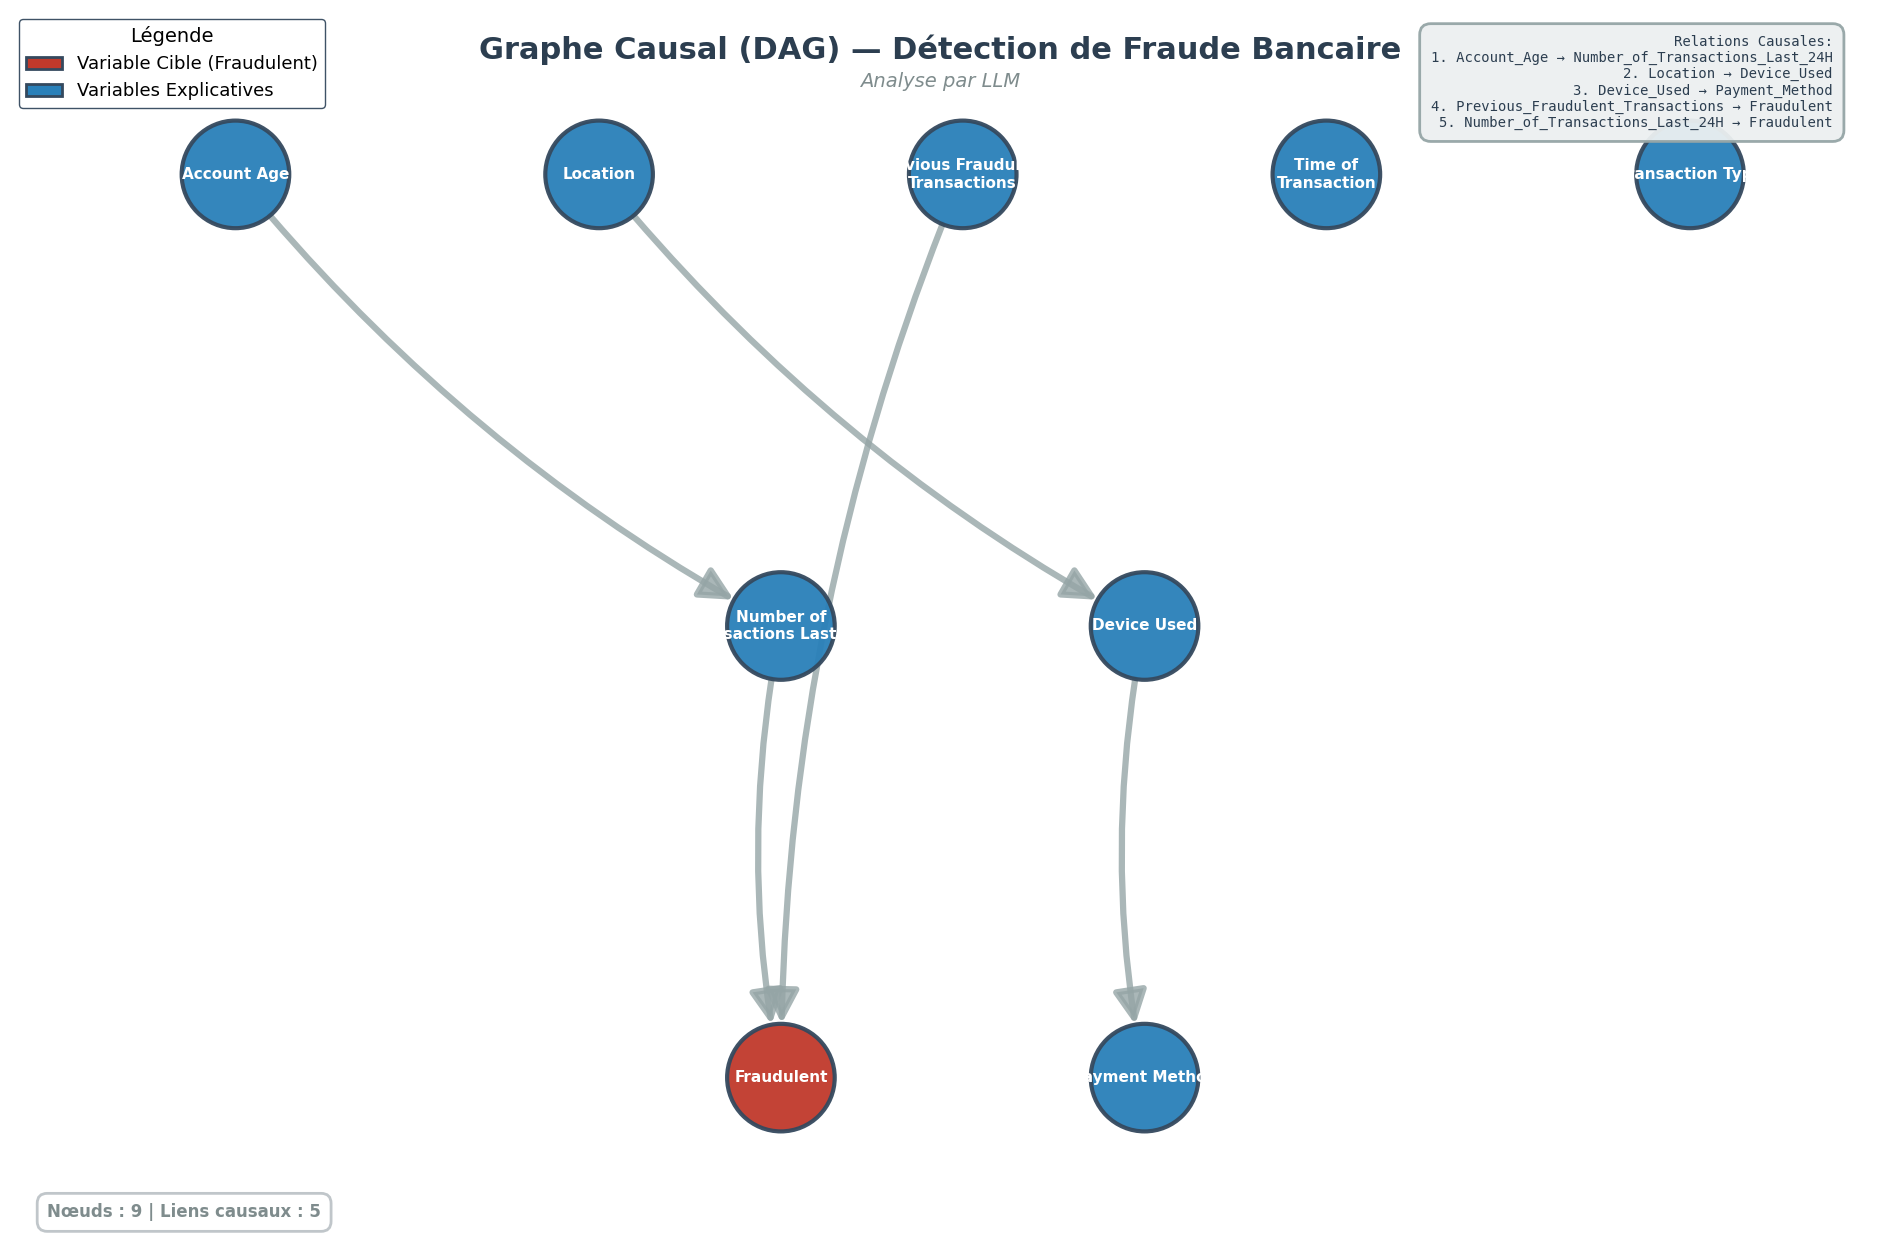


 DAG sauvegardé (PNG 300 DPI) : dag_causal_fraude.png
 DAG sauvegardé (SVG vectoriel) : dag_causal_fraude.svg


In [10]:

# ─────────────────────────────────────────────
# 9. PIPELINE PRINCIPAL
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # data = pd.read_csv("mon_dataset.csv")

    COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]

    print("=" * 70)
    print(" DÉMARRAGE DE L'INFÉRENCE CAUSALE AVEC LLM VIA API")
    print("=" * 70)
    print(f" Endpoint API : {OLLAMA_API_URL}")
    print(f" Modèle : {MODEL_NAME}")
    print(f" Vérification SSL désactivée : {SKIP_SSL_VERIFY}")
    print(f" Colonnes exclues : {', '.join(COLONNES_EXCLUES)}\n")

    # Générer le DAG 
    dag_data = interroger_llm_pour_dag(
        data,
        colonnes_exclues=COLONNES_EXCLUES,
        model_name=MODEL_NAME
    )

    afficher_resume_dag(dag_data)
    visualiser_dag(dag_data, chemin_sauvegarde="dag_causal_fraude.png")

    with open("dag_causal_fraude.json", "w", encoding="utf-8") as f:
        json.dump(dag_data, f, indent=2, ensure_ascii=False)


# Test d'independances

 DAG CAUSAL AVEC SOFTMAX
Modèle : mistral

 Interrogation du LLM...

 RÉPONSE LLM :
Based on the available data and the constraints provided, here's a possible DAG (Directed Acyclic Graph) for the causal relationship between the given variables:

```json
{
  "noeuds": ["Account_Age", "Location", "Transaction_Type", "Device_Used", "Number_of_Transactions_Last_24H", "Payment_Method", "Time_of_Transaction", "Fraudulent"],
  "liens": [
    {"de": "Account_Age", "vers": "Number_of_Transactions_Last_24H", "raison": "Older accounts may have more transactions"},
    {"de": "Location", "vers": "Transaction_Type", "raison": "Different locations might prefer different transaction types"},
    {"de": "Location", "vers": "Device_Used", "raison": "Different devices might be preferred in certain locations"},
    {"de": "Transaction_Type", "vers": "Fraudulent", "raison": "Online purchases, POS payments, bill payments, bank transfers, and ATM withdrawals can potentially involve fraud"},
    {"de": "Dev

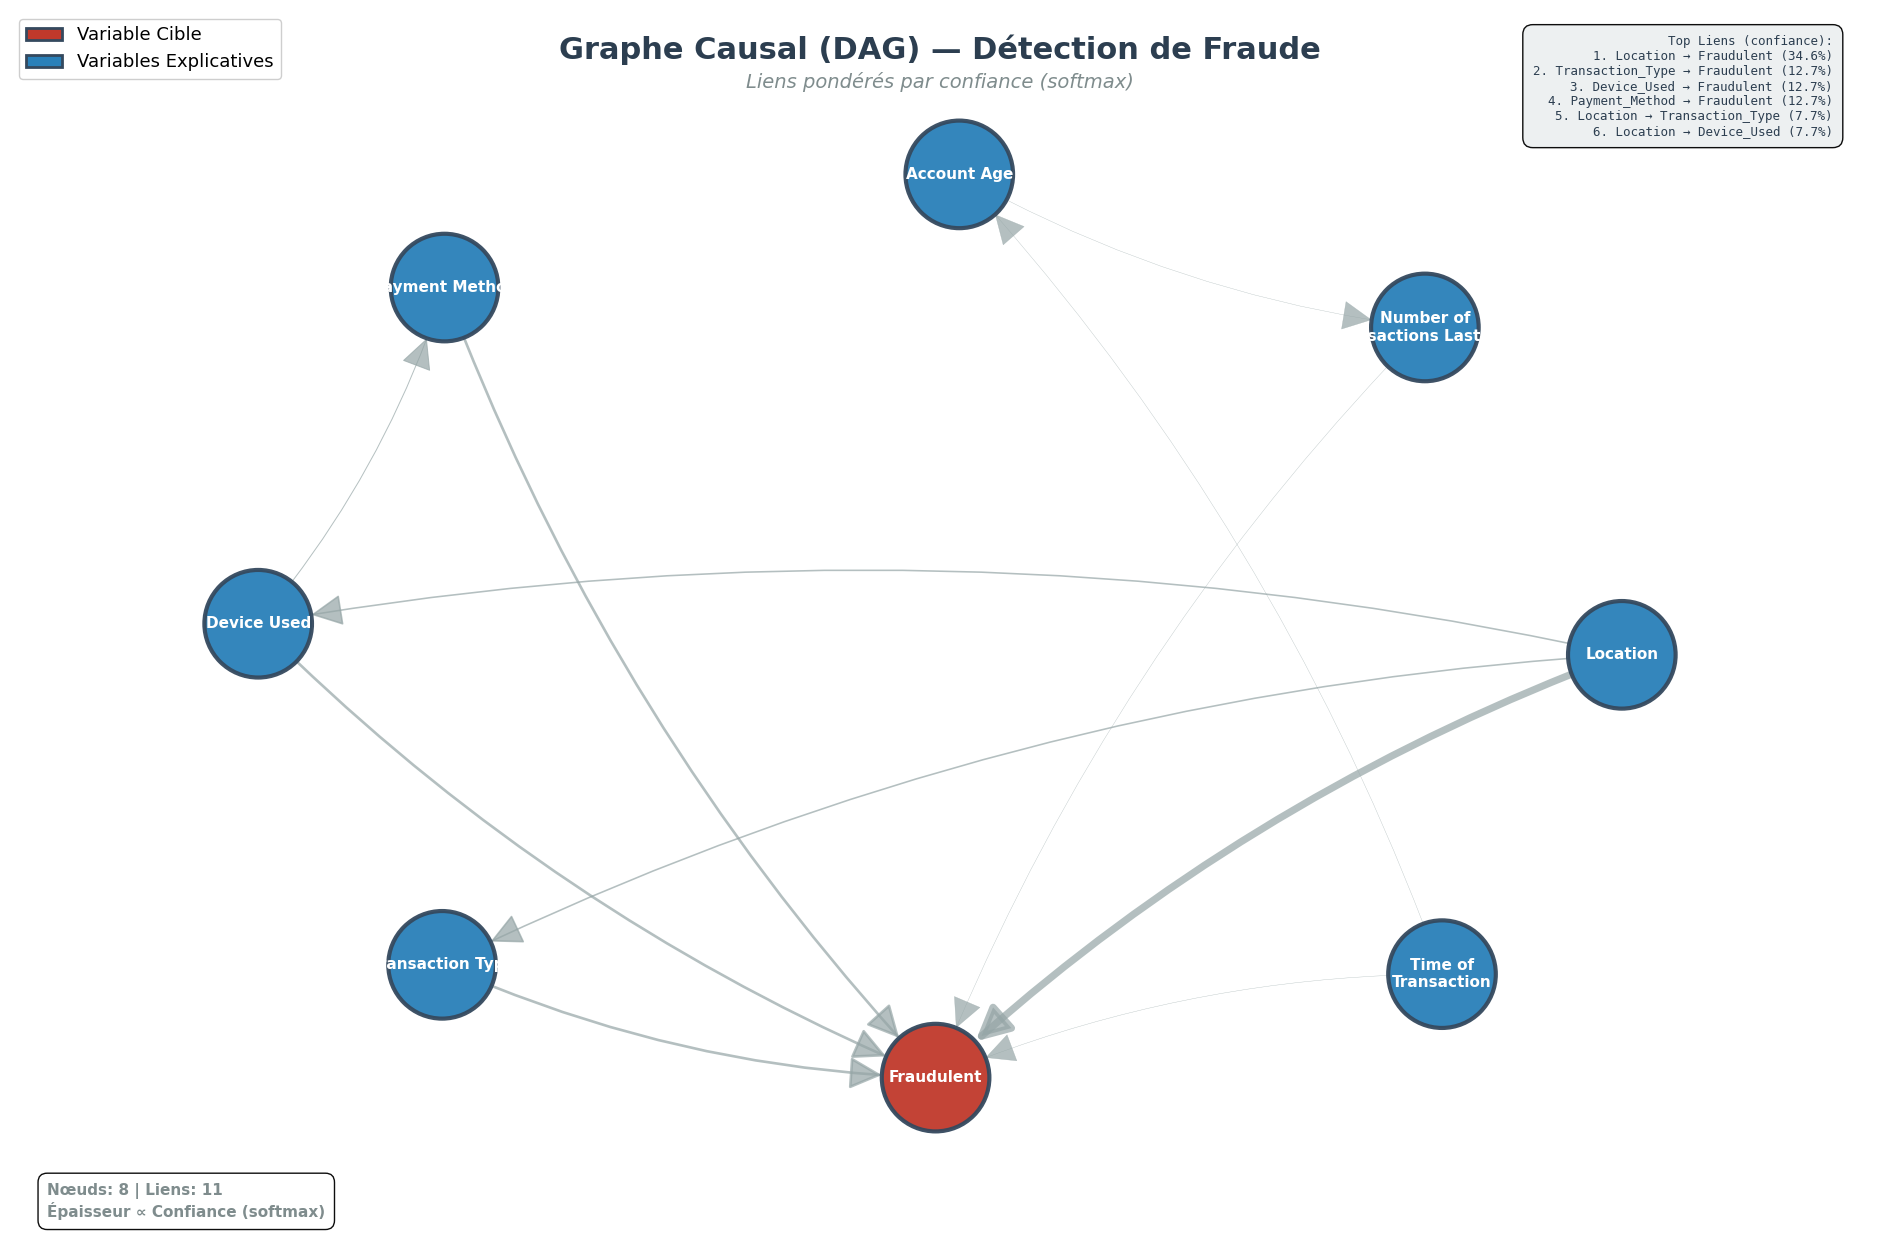


 DAG sauvegardé : dag_causal_fraude.png

 Terminé !


In [11]:
import os
import json
import re
import time
import urllib3
import requests
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# 1. CONFIGURATION API
# ─────────────────────────────────────────────

OLLAMA_API_URL = "https://ollama-api.lab.groupe-genes.fr/api/generate"
MODEL_NAME = "mistral"

SKIP_SSL_VERIFY = True
MAX_RETRIES_LOAD = 2
RETRY_DELAY_SECONDS = 2

if SKIP_SSL_VERIFY:
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


# ─────────────────────────────────────────────
# FONCTION SOFTMAX
# ─────────────────────────────────────────────
def softmax(scores, temperature=1.0):
    """
    Applique softmax pour convertir scores en probabilités.
    
    Args:
        scores: Liste ou array de scores bruts
        temperature: Contrôle la distribution (défaut=1.0)
                    T<1 = plus confiant, T>1 = plus uniforme
    
    Returns:
        Array numpy de probabilités sommant à 1
    """
    scores = np.array(scores) / temperature
    exp_scores = np.exp(scores - np.max(scores))  # Stabilité numérique
    return exp_scores / exp_scores.sum()


# ─────────────────────────────────────────────
# 2. ANALYSE STATISTIQUE DU DATASET
# ─────────────────────────────────────────────
def construire_resume_donnees(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:
    """Construit un résumé enrichi du dataset pour le LLM."""
    
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    data_filtree = data.drop(columns=colonnes_exclues, errors="ignore")
    parties_resume = []

    if "Fraudulent" in data_filtree.columns:
        taux_fraude = data_filtree["Fraudulent"].mean() * 100
        nb_frauds = int(data_filtree["Fraudulent"].sum())
        parties_resume.append(f"Dataset: {data.shape[0]} lignes, taux fraude: {taux_fraude:.1f}% ({nb_frauds} cas)")
    
    # VARIABLES QUANTITATIVES 
    colonnes_num = data_filtree.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    
    if len(colonnes_num) > 0:
        parties_resume.append(f"\nVARIABLES QUANTITATIVES :")
        for col in colonnes_num:
            if col == "Fraudulent":
                continue
            
            stats = data_filtree[col].describe()
            fraud_mean = data_filtree[data_filtree['Fraudulent'] == 1][col].mean()
            legit_mean = data_filtree[data_filtree['Fraudulent'] == 0][col].mean()
            
            parties_resume.append(f"  {col}:")
            parties_resume.append(f"    Moyenne (Fraudes)={fraud_mean:.2f} | Moyenne (Légitimes)={legit_mean:.2f}")
            parties_resume.append(f"    Min={stats['min']:.2f} | Max={stats['max']:.2f}")

    # VARIABLES QUALITATIVES 
    colonnes_cat = data_filtree.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
    
    if len(colonnes_cat) > 0:
        parties_resume.append(f"\nVARIABLES QUALITATIVES :")
        for col in colonnes_cat:
            mode_fraud_rate = data_filtree.groupby(col)['Fraudulent'].mean().sort_values(ascending=False)
            parties_resume.append(f"  {col} (taux fraude): {dict((k, f'{v*100:.0f}%') for k, v in mode_fraud_rate.items())}")

    # Corrélations - TOP 3
    if "Fraudulent" in data_filtree.columns and len(colonnes_num) > 1:
        parties_resume.append(f"\nTOP CORRÉLATIONS avec Fraudulent :")
        corr = data_filtree[colonnes_num].corr()["Fraudulent"].drop("Fraudulent", errors='ignore')
        top_corr = corr.abs().sort_values(ascending=False).head(3)
        for var in top_corr.index:
            parties_resume.append(f"  {var}: {corr[var]:.2f}")

    return "\n".join(parties_resume), data_filtree.columns.tolist(), data_filtree


# ─────────────────────────────────────────────
# 3. CONSTRUCTION DU PROMPT 
# ─────────────────────────────────────────────
def construire_prompt_dag_causal(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    resume_donnees, colonnes_pertinentes, data_filtree = construire_resume_donnees(data, colonnes_exclues)
    liste_colonnes = ", ".join(colonnes_pertinentes)

    system_prompt = f"""
Tu es un expert en inférence causale et détection de fraude bancaire.

MISSION : Construire un DAG causal RÉALISTE.

ERREUR À ÉVITER :
NE CRÉE PAS un graphe où toutes les variables pointent vers Fraudulent !

UN VRAI DAG CAUSAL doit avoir :
1. Variables ROOT (causes premières)
2. Variables INTERMÉDIAIRES (médiateurs)
3. CHEMINS CAUSAUX complexes vers Fraudulent

Variables disponibles : {liste_colonnes}
""".strip()

    user_prompt = f"""
{resume_donnees}

CONSTRUIS UN DAG CAUSAL RÉALISTE :

ÉTAPE 1 - Variables ROOT (qui ne dépendent de rien)
ÉTAPE 2 - MÉDIATEURS (influencées ET qui influencent)
ÉTAPE 3 - Variables influençant DIRECTEMENT Fraudulent (MAX 5)

CONTRAINTES :
* 50%+ des variables doivent avoir des liens ENTRE ELLES
* Fraudulent a MAXIMUM 5 parents directs
* Variables intermédiaires ont AU MOINS 1 parent ET 1 enfant

FORMAT JSON :
{{
  "noeuds": ["Account_Age", "Location", ..., "Fraudulent"],
  "liens": [
    {{"de": "Account_Age", "vers": "Number_of_Transactions_Last_24H", "raison": "justification"}},
    ...
  ],
  "commentaire_expert": "Résumé de la structure causale"
}}


RETOURNE UNIQUEMENT LE JSON.
""".strip()

    return system_prompt, user_prompt, colonnes_pertinentes, data_filtree


# ─────────────────────────────────────────────
# 4. APPEL API
# ─────────────────────────────────────────────
def appeler_api_ollama(system_prompt: str, user_prompt: str, model_name: str = MODEL_NAME) -> str:
    headers = {"Content-Type": "application/json"}
    prompt_complet = f"{system_prompt}\n\n{user_prompt}"

    payload = {
        "model": model_name,
        "prompt": prompt_complet,
        "stream": False,
        "options": {
            "temperature": 0.01,
            "top_p": 0.9,
            "top_k": 40,
            "num_predict": 2000,
        }
    }

    for tentative in range(1, MAX_RETRIES_LOAD + 2):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                headers=headers,
                json=payload,
                timeout=300,
                verify=not SKIP_SSL_VERIFY
            )
            response.raise_for_status()
        except requests.exceptions.Timeout:
            print(f"Timeout (tentative {tentative})")
            if tentative < MAX_RETRIES_LOAD + 1:
                time.sleep(RETRY_DELAY_SECONDS)
                continue
            raise RuntimeError("Timeout persistant")
        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Erreur API : {e}")

        result = response.json()
        contenu = result.get("response", "")
        if contenu.strip():
            return contenu.strip()

        if result.get("done_reason") == "load":
            time.sleep(RETRY_DELAY_SECONDS)
            continue
        break

    raise RuntimeError("Réponse vide")


def interroger_llm_pour_dag(data, colonnes_exclues=None, model_name=MODEL_NAME):
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    system_prompt, user_prompt, colonnes_pertinentes, data_filtree = construire_prompt_dag_causal(data, colonnes_exclues)

    print(" Interrogation du LLM...")
    sortie_brute = appeler_api_ollama(system_prompt, user_prompt, model_name)
    
    print("\n" + "="*70)
    print(" RÉPONSE LLM :")
    print("="*70)
    print(sortie_brute)
    print("="*70 + "\n")

    dag_data = extraire_json_reponse(sortie_brute)
    dag_data = valider_et_nettoyer_dag(dag_data, colonnes_pertinentes, data_filtree)

    return dag_data


# ─────────────────────────────────────────────
# 5. EXTRACTION JSON
# ─────────────────────────────────────────────
def extraire_json_reponse(texte_brut: str) -> dict:
    texte_nettoye = texte_brut.strip()
    if texte_nettoye.startswith("```json"):
        texte_nettoye = texte_nettoye[7:]
    if texte_nettoye.startswith("```"):
        texte_nettoye = texte_nettoye[3:]
    if texte_nettoye.endswith("```"):
        texte_nettoye = texte_nettoye[:-3]
    texte_nettoye = texte_nettoye.strip()

    try:
        parsed = json.loads(texte_nettoye)
        if _valider_structure_json(parsed):
            return _normaliser_json(parsed)
    except json.JSONDecodeError:
        pass

    motif_json = r"\{[\s\S]*\}"
    correspondances = re.findall(motif_json, texte_brut)
    for match in correspondances:
        try:
            parsed = json.loads(match)
            if _valider_structure_json(parsed):
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            continue

    return {"noeuds": [], "liens": []}


def _valider_structure_json(parsed: dict) -> bool:
    if not isinstance(parsed, dict):
        return False
    has_nodes = "noeuds" in parsed or "nodes" in parsed
    has_edges = "liens" in parsed or "edges" in parsed
    return has_nodes and has_edges


def _normaliser_json(parsed: dict) -> dict:
    if "nodes" in parsed:
        parsed["noeuds"] = parsed.pop("nodes")
    if "edges" in parsed:
        parsed["liens"] = parsed.pop("edges")
    
    for lien in parsed.get("liens", []):
        if "from" in lien:
            lien["de"] = lien.pop("from")
        if "to" in lien:
            lien["vers"] = lien.pop("to")
        if "reason" in lien:
            lien["raison"] = lien.pop("reason")
    
    return parsed


# ─────────────────────────────────────────────
# 6. VALIDATION DAG AVEC SOFTMAX
# ─────────────────────────────────────────────
def valider_et_nettoyer_dag(dag_data: dict, colonnes_pertinentes: list, data_filtree: pd.DataFrame) -> dict:
    """Valide le DAG et calcule scores de confiance avec SOFTMAX."""
    
    if "noeuds" not in dag_data or "liens" not in dag_data:
        return dag_data
    
    noeuds_valides = [n for n in dag_data["noeuds"] if n in colonnes_pertinentes]
    liens_valides = [
        lien for lien in dag_data.get("liens", [])
        if lien.get("de") in noeuds_valides and lien.get("vers") in noeuds_valides
    ]
    
    # Vérifier acyclicité
    G = nx.DiGraph()
    G.add_edges_from([(l["de"], l["vers"]) for l in liens_valides])
    
    if not nx.is_directed_acyclic_graph(G):
        print(" Cycles détectés, suppression...")
        liens_sans_cycles = []
        G_temp = nx.DiGraph()
        for lien in liens_valides:
            G_temp.add_edge(lien["de"], lien["vers"])
            if nx.is_directed_acyclic_graph(G_temp):
                liens_sans_cycles.append(lien)
            else:
                G_temp.remove_edge(lien["de"], lien["vers"])
        liens_valides = liens_sans_cycles
        G = G_temp
    
    # ═══════════════════════════════════════════
    # SOFTMAX : CALCUL DES SCORES DE CONFIANCE
    # ═══════════════════════════════════════════
    
    print("\n CALCUL DES SCORES DE CONFIANCE (softmax)...")
    
    # Calculer matrice de corrélations
    colonnes_num = data_filtree.select_dtypes(include=['int64', 'float64']).columns
    correlations = {}
    if len(colonnes_num) > 1:
        corr_matrix = data_filtree[colonnes_num].corr().abs()
        for col1 in colonnes_num:
            for col2 in colonnes_num:
                if col1 != col2:
                    correlations[(col1, col2)] = corr_matrix.loc[col1, col2]
    
    # Calculer scores pour chaque lien
    scores_bruts = []
    for lien in liens_valides:
        source, target = lien["de"], lien["vers"]
        
        # Score 1 : Corrélation (si numérique)
        corr_score = correlations.get((source, target), 0.5)
        
        # Score 2 : Structure (variables ROOT ont score élevé)
        is_root = len(list(G.predecessors(source))) == 0
        structure_score = 1.5 if is_root else 1.0
        
        # Score 3 : Priorité cible (liens vers Fraudulent)
        target_score = 2.0 if target == "Fraudulent" else 1.0
        
        # Score combiné
        score_total = corr_score * structure_score * target_score
        scores_bruts.append(score_total)
        lien['score_brut'] = score_total
    
    # Appliquer SOFTMAX
    if scores_bruts:
        # Temperature = 0.5 pour accentuer les différences
        probas_softmax = softmax(scores_bruts, temperature=0.5)
        
        for i, lien in enumerate(liens_valides):
            lien['confiance'] = float(probas_softmax[i])
            lien['confiance_pct'] = f"{probas_softmax[i]*100:.1f}%"
        
        # Trier par confiance
        liens_valides = sorted(liens_valides, key=lambda x: x['confiance'], reverse=True)
        
        print(f"\n TOP 8 LIENS PAR CONFIANCE :")
        for i, lien in enumerate(liens_valides[:8], 1):
            print(f"  {i}. {lien['de']:25} → {lien['vers']:25} | {lien['confiance_pct']} (score={lien['score_brut']:.2f})")
    
    dag_data["noeuds"] = noeuds_valides
    dag_data["liens"] = liens_valides
    
    print(f"\n DAG validé : {len(noeuds_valides)} nœuds, {len(liens_valides)} liens")
    
    return dag_data


# ─────────────────────────────────────────────
# 7. VISUALISATION AVEC ÉPAISSEUR SELON CONFIANCE
# ─────────────────────────────────────────────
def visualiser_dag(dag_data: dict, chemin_sauvegarde: str = "dag_causal_fraude.png"):
    """Visualise le DAG avec épaisseur des flèches proportionnelle à la confiance."""

    if not dag_data.get("liens"):
        print(" Aucun lien")
        return

    G = nx.DiGraph()
    G.add_nodes_from(dag_data["noeuds"])
    
    # Ajouter poids (confiance) aux arêtes
    for lien in dag_data["liens"]:
        weight = lien.get('confiance', 0.1)
        G.add_edge(lien["de"], lien["vers"], weight=weight, raison=lien.get("raison", ""))

    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args="-Grankdir=TB -Gnodesep=2.0 -Granksep=3.0")
    except:
        pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

    fig, ax = plt.subplots(figsize=(24, 16), facecolor='white')
    
    ax.text(0.5, 0.98, "Graphe Causal (DAG) — Détection de Fraude", 
            transform=ax.transAxes, fontsize=22, fontweight='bold',
            ha='center', va='top', color='#2c3e50')
    ax.text(0.5, 0.95, "Liens pondérés par confiance (softmax)", 
            transform=ax.transAxes, fontsize=14, style='italic',
            ha='center', va='top', color='#7f8c8d')

    couleur_cible = "#c0392b"
    couleur_feature = "#2980b9"
    couleur_edge = "#95a5a6"
    
    couleurs_noeuds = [couleur_cible if n == "Fraudulent" else couleur_feature for n in G.nodes()]
    
    # Nœuds
    nx.draw_networkx_nodes(
        G, pos, node_color=couleurs_noeuds, node_size=6000,
        alpha=0.95, edgecolors='#34495e', linewidths=3, ax=ax
    )
    
    # Labels
    labels_noeuds = {}
    for noeud in G.nodes():
        if len(noeud) > 18:
            parties = noeud.replace('_', ' ').split()
            if len(parties) > 2:
                labels_noeuds[noeud] = ' '.join(parties[:2]) + '\n' + ' '.join(parties[2:])
            else:
                labels_noeuds[noeud] = noeud.replace('_', '\n', 1)
        else:
            labels_noeuds[noeud] = noeud.replace('_', ' ')
    
    nx.draw_networkx_labels(
        G, pos, labels=labels_noeuds, font_size=11,
        font_weight='bold', font_color='white', ax=ax
    )
    
    # Arêtes avec ÉPAISSEUR PROPORTIONNELLE à la confiance
    edges = G.edges(data=True)
    widths = [edge[2].get('weight', 0.1) * 15 for edge in edges]  # Scale x15
    
    nx.draw_networkx_edges(
        G, pos, arrows=True, arrowsize=50, arrowstyle='-|>',
        edge_color=couleur_edge, width=widths,  # ← Épaisseur variable !
        connectionstyle="arc3,rad=0.1", alpha=0.7,
        node_size=6000, min_source_margin=25, min_target_margin=25, ax=ax
    )
    
    # Légende
    legende = [
        mpatches.Patch(facecolor=couleur_cible, edgecolor='#34495e', linewidth=2, 
                      label="Variable Cible"),
        mpatches.Patch(facecolor=couleur_feature, edgecolor='#34495e', linewidth=2,
                      label="Variables Explicatives"),
    ]
    ax.legend(handles=legende, loc='upper left', fontsize=13, framealpha=0.95)
    
    # Stats
    info_text = f"Nœuds: {len(G.nodes())} | Liens: {len(G.edges())}\nÉpaisseur ∝ Confiance (softmax)"
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes,
           fontsize=11, color='#7f8c8d', weight='bold',
           bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.95))
    
    # Top liens
    relations_top = []
    for i, lien in enumerate(dag_data["liens"][:6], 1):
        conf = lien.get('confiance_pct', 'N/A')
        relations_top.append(f"{i}. {lien['de']} → {lien['vers']} ({conf})")
    
    if relations_top:
        relations_text = "Top Liens (confiance):\n" + "\n".join(relations_top)
        ax.text(0.98, 0.98, relations_text, transform=ax.transAxes,
               fontsize=9, color='#2c3e50', ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', alpha=0.95),
               family='monospace')
    
    ax.axis('off')
    ax.margins(0.12)
    
    plt.savefig(chemin_sauvegarde, dpi=300, bbox_inches="tight", facecolor='white')
    chemin_svg = chemin_sauvegarde.replace('.png', '.svg')
    plt.savefig(chemin_svg, format='svg', bbox_inches="tight", facecolor='white')
    
    plt.show()
    print(f"\n DAG sauvegardé : {chemin_sauvegarde}")


# ─────────────────────────────────────────────
# 8. AFFICHAGE
# ─────────────────────────────────────────────
def afficher_resume_dag(dag_data: dict):
    print("\n" + "="*70)
    print(" GRAPHE CAUSAL (DAG) — AVEC SCORES SOFTMAX")
    print("="*70)

    if "commentaire_expert" in dag_data:
        print(f"\n {dag_data['commentaire_expert']}\n")

    print(f" Nœuds ({len(dag_data.get('noeuds', []))}) :")
    for noeud in dag_data.get("noeuds", []):
        print(f"   • {noeud}")

    print(f"\n  Liens causaux ({len(dag_data.get('liens', []))}) :")
    for lien in dag_data.get("liens", []):
        conf = lien.get('confiance_pct', 'N/A')
        print(f"   {lien['de']:30} → {lien['vers']:30} | Confiance: {conf}")
        print(f"      └─ {lien.get('raison', '')}")

    print("="*70)


# ─────────────────────────────────────────────
# 9. PIPELINE
# ─────────────────────────────────────────────
if __name__ == "__main__":
    COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]

    print("="*70)
    print(" DAG CAUSAL AVEC SOFTMAX")
    print("="*70)
    print(f"Modèle : {MODEL_NAME}\n")

    dag_data = interroger_llm_pour_dag(data, COLONNES_EXCLUES, MODEL_NAME)
    afficher_resume_dag(dag_data)
    visualiser_dag(dag_data)

    with open("dag_causal_fraude.json", "w", encoding="utf-8") as f:
        json.dump(dag_data, f, indent=2, ensure_ascii=False)
    
    print("\n Terminé !")

In [12]:


# CONFIG
MODEL_NAME = "mistral"


def interpreter_dag(fichier_dag: str = "dag_causal_fraude.json"):
    """Charge un DAG et demande au LLM de l'interpréter."""
    
    # Charger DAG
    print(f" Chargement de {fichier_dag}...")
    with open(fichier_dag, 'r', encoding='utf-8') as f:
        dag = json.load(f)
    
    print(f" DAG chargé : {len(dag['noeuds'])} nœuds, {len(dag['liens'])} liens\n")
    
    # Représentation texte du DAG
    dag_text = f"NŒUDS ({len(dag['noeuds'])}) : {', '.join(dag['noeuds'])}\n\nLIENS CAUSAUX ({len(dag['liens'])}) :\n"
    for i, lien in enumerate(dag['liens'], 1):
        conf = lien.get('confiance_pct', '')
        dag_text += f"{i}. {lien['de']} → {lien['vers']}"
        if conf:
            dag_text += f" [{conf}]"
        dag_text += f"\n   {lien.get('raison', '')}\n"
    
    # Prompts
    system_prompt = """Tu es un expert senior en fraude financière et détection de transactions suspectes."""
    
    user_prompt = f"""Analyse ce DAG de détection de fraude :

{dag_text}

Retourne UNIQUEMENT un JSON avec cette structure :
{{
  "mecanismes_causaux": "Explique en 3-5 phrases comment les variables interagissent pour produire la fraude",
  "signaux_fraude": "Liste les 3-4 signaux clés de fraude identifiés",
  "recommandations": "Propose 2-3 actions concrètes pour améliorer la détection",
  "vulnerabilites": "Identifie 1-2 failles exploitables par les fraudeurs"
}}

Sois CONCRET et ACTIONNABLE. Retourne UNIQUEMENT le JSON."""
    
    # Appel LLM (réutilise la fonction existante)
    print(" Interrogation du LLM pour interprétation experte...\n")
    reponse = appeler_api_ollama(system_prompt, user_prompt, MODEL_NAME)
    
    print("="*80)
    print(" RÉPONSE BRUTE :")
    print("="*80)
    print(reponse)
    print("="*80 + "\n")
    
    # Extraire JSON
    reponse_clean = reponse.strip()
    if reponse_clean.startswith("```json"):
        reponse_clean = reponse_clean[7:]
    if reponse_clean.startswith("```"):
        reponse_clean = reponse_clean[3:]
    if reponse_clean.endswith("```"):
        reponse_clean = reponse_clean[:-3]
    reponse_clean = reponse_clean.strip()
    
    try:
        interp = json.loads(reponse_clean)
    except:
        match = re.search(r'\{[\s\S]*\}', reponse)
        interp = json.loads(match.group()) if match else {"erreur": "JSON non trouvé", "texte_brut": reponse}
    
    # Afficher interprétation
    print("="*80)
    print(" INTERPRÉTATION EXPERT EN FRAUDE FINANCIÈRE")
    print("="*80)
    
    if "mecanismes_causaux" in interp:
        print(f"\n MÉCANISMES CAUSAUX :")
        print(f"   {interp['mecanismes_causaux']}")
    
    if "signaux_fraude" in interp:
        print(f"\n SIGNAUX D'ALERTE :")
        print(f"   {interp['signaux_fraude']}")
    
    if "recommandations" in interp:
        print(f"\n RECOMMANDATIONS :")
        print(f"   {interp['recommandations']}")
    
    if "vulnerabilites" in interp:
        print(f"\n  VULNÉRABILITÉS :")
        print(f"   {interp['vulnerabilites']}")
    
    print("\n" + "="*80)
    
    # Sauvegarder
    with open("interpretation_experte.json", 'w', encoding='utf-8') as f:
        json.dump(interp, f, indent=2, ensure_ascii=False)
    print("\n Sauvegardé : interpretation_experte.json")
    
    return interp


if __name__ == "__main__":
    try:
        interpreter_dag("dag_causal_fraude.json")
        print("\n Terminé !")
    except FileNotFoundError:
        print("\n Fichier dag_causal_fraude.json introuvable.")
        print(" Génère d'abord le DAG avec le script principal.")
    except Exception as e:
        print(f"\n Erreur : {e}")

 Chargement de dag_causal_fraude.json...
 DAG chargé : 8 nœuds, 11 liens

 Interrogation du LLM pour interprétation experte...

 RÉPONSE BRUTE :
{
  "mecanismes_causaux": "The variables interact to produce fraud by certain locations having higher rates of fraud for specific transaction types, using particular devices, and preferring certain payment methods. The number of transactions in the last 24 hours and time of transaction also contribute to the likelihood of fraud.",
  "signaux_fraude": "Key indicators of fraud include unusual location, uncommon transaction type, use of suspicious devices, preferred payment methods associated with fraud, high number of transactions within a short period, and specific times of transactions.",
  "recommandations": "To improve detection, consider implementing geolocation verification for transactions, monitoring accounts with an increased number of transactions in the last 24 hours, analyzing transaction patterns during peak hours, and regularly upd